In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import tensorflow as tf
from tensorflow import keras


from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

In [3]:
dataset_path = "../dataset/PlantVillage"

train_path = os.path.join(dataset_path, "train")
val_path = os.path.join(dataset_path, "val")

IMG_SIZE = (160, 160)
BATCH_SIZE = 32

print("Validation path:", val_path)

Validation path: ../dataset/PlantVillage\val


In [4]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = val_ds.class_names

print("Jumlah kelas:", len(class_names))

for i, class_name in enumerate(class_names):
    print(i, class_name)

Found 10861 files belonging to 38 classes.
Jumlah kelas: 38
0 Apple___Apple_scab
1 Apple___Black_rot
2 Apple___Cedar_apple_rust
3 Apple___healthy
4 Blueberry___healthy
5 Cherry_(including_sour)___Powdery_mildew
6 Cherry_(including_sour)___healthy
7 Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
8 Corn_(maize)___Common_rust_
9 Corn_(maize)___Northern_Leaf_Blight
10 Corn_(maize)___healthy
11 Grape___Black_rot
12 Grape___Esca_(Black_Measles)
13 Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14 Grape___healthy
15 Orange___Haunglongbing_(Citrus_greening)
16 Peach___Bacterial_spot
17 Peach___healthy
18 Pepper,_bell___Bacterial_spot
19 Pepper,_bell___healthy
20 Potato___Early_blight
21 Potato___Late_blight
22 Potato___healthy
23 Raspberry___healthy
24 Soybean___healthy
25 Squash___Powdery_mildew
26 Strawberry___Leaf_scorch
27 Strawberry___healthy
28 Tomato___Bacterial_spot
29 Tomato___Early_blight
30 Tomato___Late_blight
31 Tomato___Leaf_Mold
32 Tomato___Septoria_leaf_spot
33 Tomato___Spider_

In [5]:
AUTOTUNE = tf.data.AUTOTUNE

val_ds = val_ds.prefetch(AUTOTUNE)

print("Validation dataset siap.")

Validation dataset siap.


In [6]:
model_path = "../models/plant_disease_mobilenetv2.keras"

model = keras.models.load_model(model_path)

print("Model berhasil dimuat.")

Model berhasil dimuat.


In [7]:
loss, accuracy = model.evaluate(val_ds, verbose=1)

print("\nValidation Loss:", loss)
print("Validation Accuracy:", accuracy)

340/340 ━━━━━━━━━━━━━━━━━━━━ 76s 217ms/step - accuracy: 0.9174 - loss: 0.2501

Validation Loss: 0.2501169443130493
Validation Accuracy: 0.9174109101295471


In [8]:
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Jumlah label:", len(y_true))
print("Jumlah prediksi:", len(y_pred))

Jumlah label: 10861
Jumlah prediksi: 10861


In [11]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.8779    0.9127    0.8949       126
                                 Apple___Black_rot     0.9185    0.9920    0.9538       125
                          Apple___Cedar_apple_rust     0.9167    1.0000    0.9565        55
                                   Apple___healthy     0.9339    0.9453    0.9396       329
                               Blueberry___healthy     0.9770    0.9900    0.9834       300
          Cherry_(including_sour)___Powdery_mildew     1.0000    0.9286    0.9630       210
                 Cherry_(including_sour)___healthy     0.9940    0.9706    0.9821       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.7795    0.9612    0.8609       103
                       Corn_(maize)___Common_rust_     0.9874    0.9833    0.9853       239
               Corn_(maize)___Northern_Leaf_Blight     0.9770    0.8629    0.91

In [12]:
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()

report_df

,precision,recall,f1-score,support
Apple___Apple_scab,0.877863,0.912698,0.894942,126.000000
Apple___Black_rot,0.918519,0.992000,0.953846,125.000000
Apple___Cedar_apple_rust,0.916667,1.000000,0.956522,55.000000
Apple___healthy,0.933934,0.945289,0.939577,329.000000
Blueberry___healthy,0.976974,0.990000,0.983444,300.000000
Cherry_(including_sour)___Powdery_mildew,1.000000,0.928571,0.962963,210.000000
Cherry_(including_sour)___healthy,0.993976,0.970588,0.982143,170.000000
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,0.779528,0.961165,0.860870,103.000000
Corn_(maize)___Common_rust_,0.987395,0.983264,0.985325,239.000000
Corn_(maize)___Northern_Leaf_Blight,0.977011,0.862944,0.916442,197.000000


In [13]:
class_report = report_df.iloc[:len(class_names)]

class_report = class_report.sort_values(
    by="f1-score"
)

print("5 kelas dengan F1-score terendah:")
print(
    class_report[
        ["precision", "recall", "f1-score", "support"]
    ].head()
)

5 kelas dengan F1-score terendah:
                                               precision    recall  f1-score  \
Tomato___Early_blight                           0.850467  0.455000  0.592834   
Tomato___Target_Spot                            0.522145  0.797153  0.630986   
Tomato___Spider_mites Two-spotted_spider_mite   0.748447  0.719403  0.733638   
Tomato___Septoria_leaf_spot                     0.921811  0.632768  0.750419   
Tomato___Tomato_mosaic_virus                    0.620690  0.972973  0.757895   

                                               support  
Tomato___Early_blight                            200.0  
Tomato___Target_Spot                             281.0  
Tomato___Spider_mites Two-spotted_spider_mite    335.0  
Tomato___Septoria_leaf_spot                      354.0  
Tomato___Tomato_mosaic_virus                      74.0  


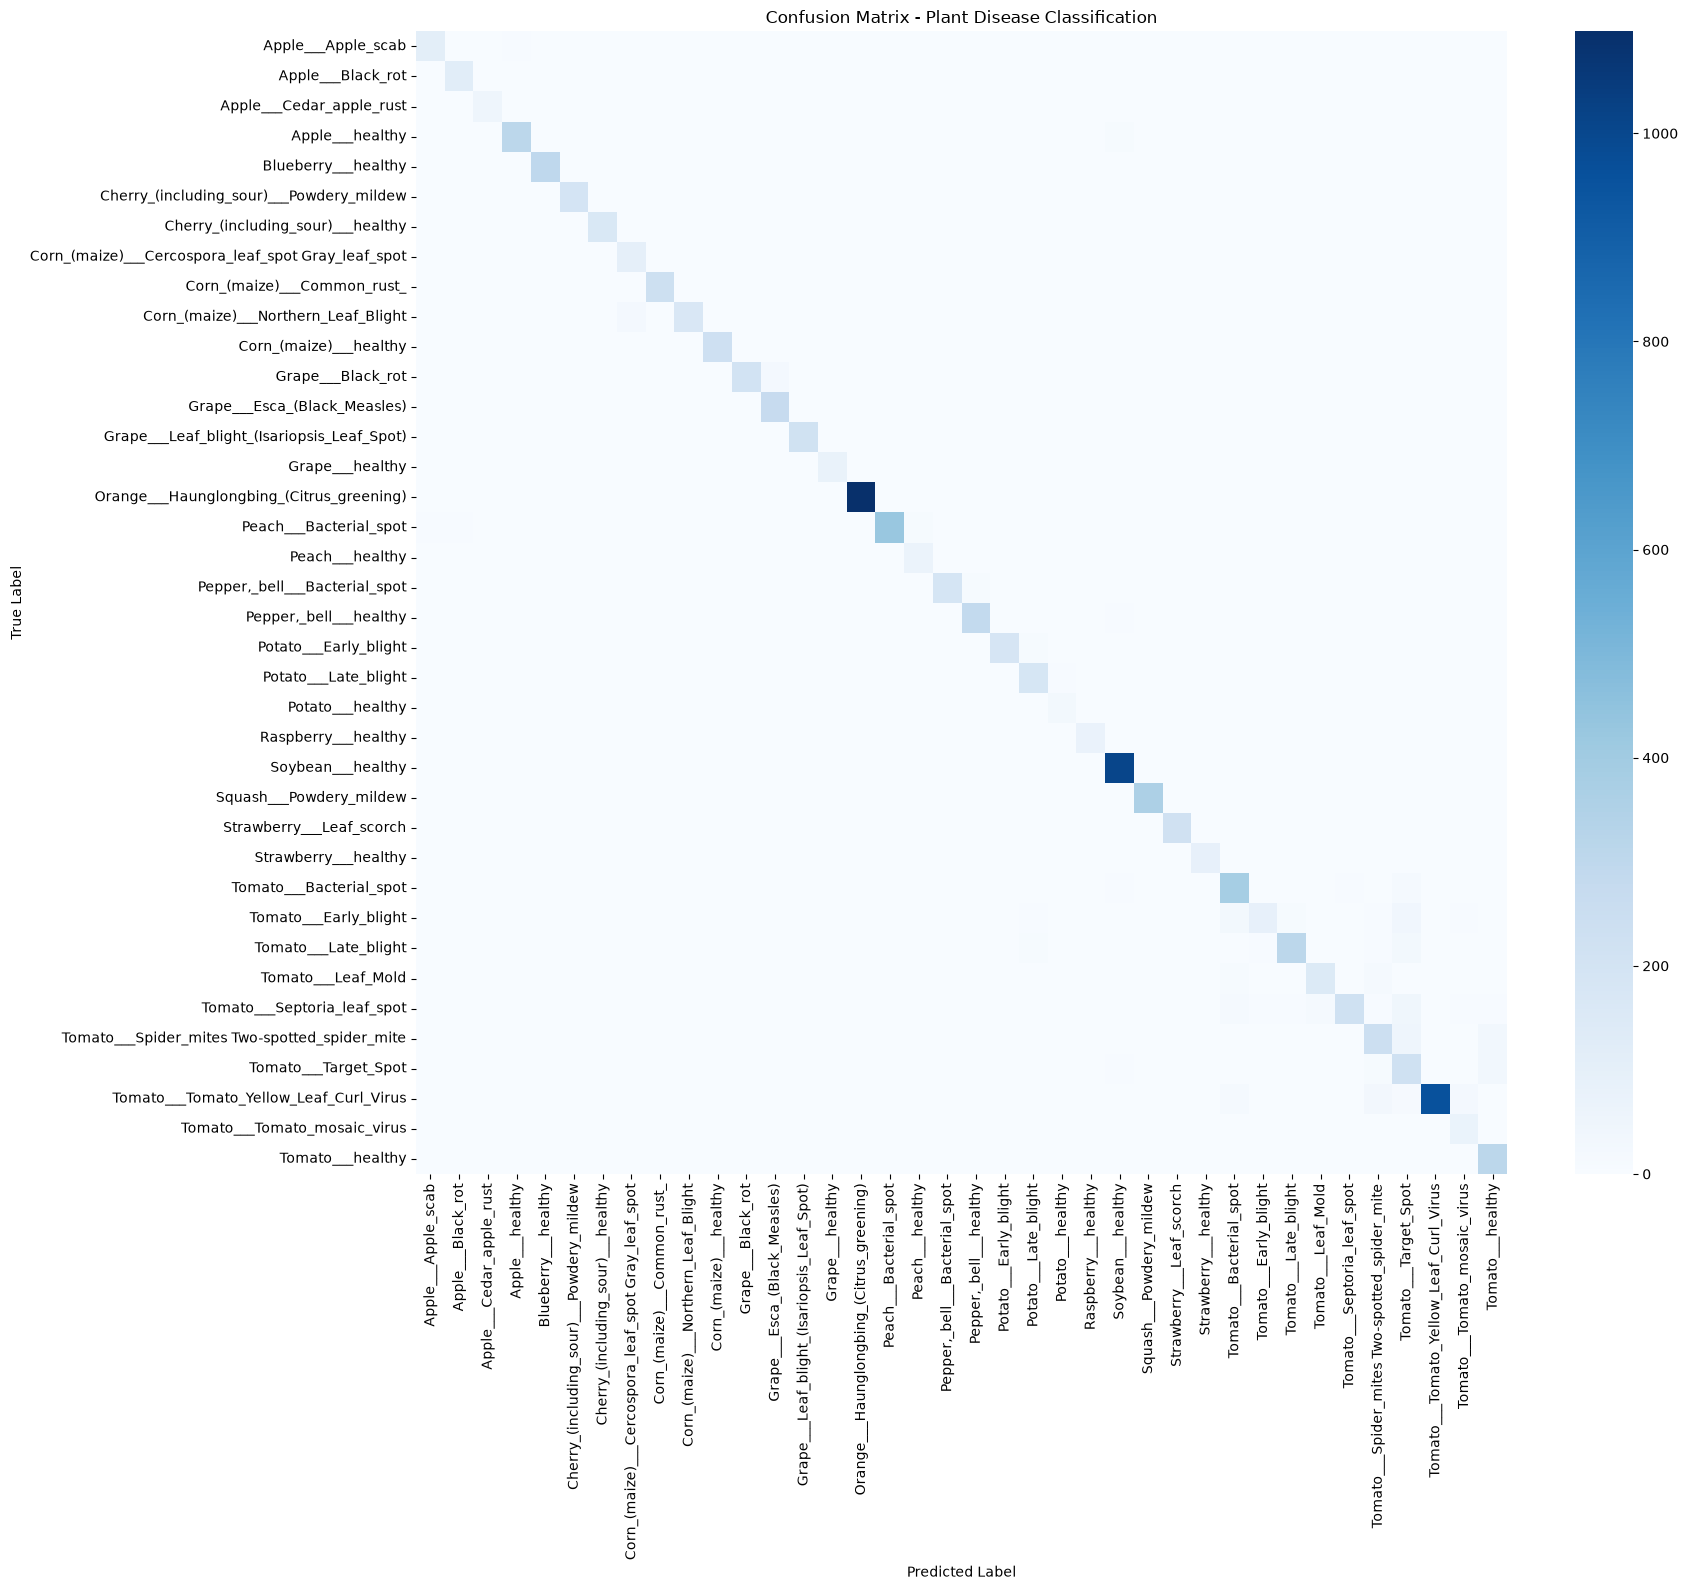

In [14]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(18, 16))

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Plant Disease Classification")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()